# OpenBind-HIPPO

- **Target: A71EV2A**
- **Cycle: 01**

## Imports

In [5]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
import pandas as pd
import plotly.express as px

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [2]:
target_name = "D68EV3C"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [37]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite", 
                     copy_from="/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C_1GDPSW3.sqlite", 
                     overwrite_existing=True,
                    )

 Creating HIPPO animal

name = D68EV3C

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite

 Warning  Overwriting /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite!

Copying /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C_1GDPSW3.sqlite --> 
/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite

...

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite!

 Success  Initialised animal HIPPO("D68EV3C")!

## Check Elabs

In [ ]:
elab_dir = Path("cycle_01/syndirella/elabs")

In [ ]:
dfs = []
files = list(elab_dir.glob("*/*output*.csv"))
mrich.var("#CSVs", len(files))
for file in files:
    df = pd.read_csv(file)
    dfs.append(df)

In [ ]:
df = pd.concat(dfs)
df.to_csv(elab_dir / "summary.csv")

In [ ]:
counts = (
    df[["error_type", "error_message"]]
    .dropna(subset=["error_type"])
    .value_counts()
    .reset_index(name="count")
)
with open(elab_dir / "errors.csv", "wt") as f:
    for _, row in counts.iterrows():
        f.write(f"{row['error_type']},{row['error_message']},{row['count']}\n")

In [ ]:
df.head()

In [ ]:
px.bar(df, x="compound_set", y="total_num_unique_products")

## Add some elaborations

In [6]:
df = pd.read_pickle("cycle_01/syndirella/elabs/d68ev3c_c01_elabs_C30265/HPHZYKNWMVBKKR-UHFFFAOYSA-N/HPHZYKNWMVBKKR-UHFFFAOYSA-N_bb016eada0d39ab85709150626b74ab8_to_hippo.pkl.gz")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /opt/xchem-fragalysis-2/maxwin/conda/lib/python3.12/site-packages/pandas/io/pickle.py:202 in     │
│ read_pickle                                                                                      │
│                                                                                                  │
│   199 │   │   │   │   with warnings.catch_warnings(record=True):                                 │
│   200 │   │   │   │   │   # We want to silence any warnings about, e.g. moved modules.           │
│   201 │   │   │   │   │   warnings.simplefilter("ignore", Warning)                               │
│ ❱ 202 │   │   │   │   │   return pickle.load(handles.handle)                                     │
│   203 │   │   │   except excs_to_catch:                                                          │
│   204 │   │   │   │   # e.g.                                                                     │
│   205 │   │   │   │   #  "No module named 'pandas.core.sparse.series'"                           │
│                                                                                                  │
│ ╭─────────────────────────────────────────── locals ───────────────────────────────────────────╮ │
│ │        compression = 'infer'                                                                 │ │
│ │      excs_to_catch = (                                                                       │ │
│ │                      │   <class 'AttributeError'>,                                           │ │
│ │                      │   <class 'ImportError'>,                                              │ │
│ │                      │   <class 'ModuleNotFoundError'>,                                      │ │
│ │                      │   <class 'TypeError'>                                                 │ │
│ │                      )                                                                       │ │
│ │ filepath_or_buffer = 'cycle_01/syndirella/elabs/d68ev3c_c01_elabs_C30265/HPHZYKNWMVBKKR-UHF… │ │
│ │            handles = IOHandles(                                                              │ │
│ │                      │   handle=<gzip on 0x7fcbe7eb8dc0>,                                    │ │
│ │                      │   compression={'method': 'gzip'},                                     │ │
│ │                      │   created_handles=[],                                                 │ │
│ │                      │   is_wrapped=False                                                    │ │
│ │                      )                                                                       │ │
│ │    storage_options = None                                                                    │ │
│ ╰──────────────────────────────────────────────────────────────────────────────────────────────╯ │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
ModuleNotFoundError: No module named 'numpy._core.numeric'

During handling of the above exception, another exception occurred:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 df = pd.read_pickle("cycle_01/syndirella/elabs/d68ev3c_c01_elabs_C30265/HPHZYKNWMVBKKR-U     │
│   2                                                                                              │
│                                                                                                  │
│ ╭─────────────────────────────────────────── locals ───────────────────────────────────────────╮ │
│ │     environ = environ({                                                                      │ │
│ │               │   'HYDRA_LAUN

In [ ]:
df.head()

In [13]:
sql = """
        INSERT INTO reaction(reaction_type, reaction_product, reaction_product_yield)
        VALUES(?1, ?2, 1)
        RETURNING reaction_id
        """

records = animal.db.executemany(sql, [('Amidation', 98112)])
records

[(444,)]

In [14]:
sql = """
        INSERT OR IGNORE INTO reactant(reactant_amount, reactant_reaction, reactant_compound)
        VALUES(1.0, ?1, ?2)
        """

payload = [(records[0][0], 98110), (records[0][0], 98111)]
print(payload)
animal.db.executemany(sql, payload)
animal.db.commit()

[(444, 98110), (444, 98111)]

In [36]:
df = animal.add_syndirella_elabs(
    "cycle_01/syndirella/elabs/d68ev3c_c01_elabs_C30265/HPHZYKNWMVBKKR-UHFFFAOYSA-N/HPHZYKNWMVBKKR-UHFFFAOYSA-N_bb016eada0d39ab85709150626b74ab8_to_hippo.pkl.gz",
    scaffold_route=animal.db.get_route(id=272),
    dry_run=False,
)

╭──────────────────────────────────────────────────────────────────────────────╮
│ HPHZYKNWMVBKKR-UHFFFAOYSA-N_bb016eada0d39ab85709150626b74ab8_to_hippo.pkl.gz │
╰──────────────────────────────────────────────────────────────────────────────╯

 DISK  Reading 
cycle_01/syndirella/elabs/d68ev3c_c01_elabs_C30265/HPHZYKNWMVBKKR-UHFFFAOYSA-N/HPHZYKNWMVBKKR-UHFFFAOYSA-N_bb016ead
a0d39ab85709150626b74ab8_to_hippo.pkl.gz...

num_steps = 1

 Warning  Flags in DataFrame: {'selectivity_issue_contains_reaction_atoms_of_both_reactants'}!

Filtering out 68 rows from step 1 due to selectivity_issue_contains_reaction_atoms_of_both_reactants

...

#poses ∆∆G > 0.0 = 0

#poses comRMSD > 2.0 = 4

#acceptable poses = 4

DEBUG: Registering 4 poses...

 Success  Registered 4 new poses!

In [38]:
routes = hippo.RouteSet.from_product_ids(animal.db, [30265])
print(routes.ids)
print(routes[0])

Output()

dict_keys([272])

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 routes = hippo.RouteSet.from_product_ids(animal.db, [30265])                                 │
│   2 print(routes.ids)                                                                            │
│ ❱ 3 print(routes[0])                                                                             │
│   4                                                                                              │
│                                                                                                  │
│ ╭─────────────────────────────────────────── locals ───────────────────────────────────────────╮ │
│ │ aligned_dir = PosixPath('/opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/aligned_fi… │ │
│ │      animal = HIPPO("D68EV3C")                                                               │ │
│ │   cycle_dir = PosixPath('cycle_01')                                                          │ │
│ │  cycle_name = 'cycle_01'                                                                     │ │
│ │          df = │   │   │   │   │   │   │   scaffold_smiles 1_reaction  \                      │ │
│ │               0   NC(Cc1cc[nH]n1)C(=O)NCCc1cccc2cc[nH]c12  Amidation                         │ │
│ │               56              c1cc([C@@H]2CCCN2)n2ccnc2n1  Amidation                         │ │
│ │               57              c1cc([C@@H]2CCCN2)n2ccnc2n1  Amidation                         │ │
│ │               58              c1cc([C@@H]2CCCN2)n2ccnc2n1  Amidation                         │ │
│ │               59              c1cc([C@@H]2CCCN2)n2ccnc2n1  Amidation                         │ │
│ │               │   │   │   │                                                                  │ │
│ │               │   │   │   │      1_r1_smiles             1_r2_smiles  \                      │ │
│ │               0          NCCc1cccc2cc[nH]c12   NC(Cc1cc[nH]n1)C(=O)O                         │ │
│ │               56  O=C1NC(C(=O)O)Cc2[nH]ncc21  COC(=O)C(N)Cc1cc[nH]n1                         │ │
│ │               57  O=C1NC(C(=O)O)Cc2[nH]ncc21  COC(=O)C(N)Cc1cc[nH]n1                         │ │
│ │               58  O=C1NC(C(=O)O)Cc2[nH]ncc21  COC(=O)C(N)Cc1cc[nH]n1                         │ │
│ │               59  O=C1NC(C(=O)O)Cc2[nH]ncc21  COC(=O)C(N)Cc1cc[nH]n1                         │ │
│ │               │   │   │   │   │   │   │   │   │                                              │ │
│ │               │   │   │   │   │   │   │   │   │    1_product_smiles  \                       │ │
│ │               0             NC(Cc1cc[nH]n1)C(=O)NCCc1cccc2cc[nH]c12                          │ │
│ │               56  COC(=O)[C@H](Cc1cc[nH]n1)NC(=O)[C@@H]1Cc2[nH]n...                          │ │
│ │               57  COC(=O)[C@@H](Cc1cc[nH]n1)NC(=O)[C@@H]1Cc2[nH]...                          │ │
│ │               58  COC(=O)[C@H](Cc1cc[nH]n1)NC(=O)[C@H]1Cc2[nH]nc...                          │ │
│ │               59  COC(=O)[C@@H](Cc1cc[nH]n1)NC(=O)[C@H]1Cc2[nH]n...                          │ │
│ │               │   │   │   │   │   │   │   │   │                                              │ │
│ │               │   │   │   │   │   │   │   │   │      1_product_name  1_single_reactant_elab  │ │
│ │               \                                                                              │ │
│ │               0                                            scaffold                   False  │ │
│ │               56  HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d39ab857...                   False  │ │
│ │               57  HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d39ab857...                   False  │ │
│ │               58  HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d

In [20]:
route = animal.db.get_route(id=272)
route.summary()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                               ROUTE #272: C30265                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

price = 493.0 EUR

╭────────────╮
│ 1 products │
╰────────────╯

C30265 = 1.00 mg

╭─────────────╮
│ 2 reactants │
╰─────────────╯

C97926 = 1.00 mg

C97927 = 1.00 mg

╭─────────────╮
│ 1 reactions │
╰─────────────╯

R413 = C97926 + C97927 -> C30265 Amidation

In [23]:
route.products[0].compound

C30265 "XSRXGMUGZYCKQU-UHFFFAOYSA-N"

In [26]:
df

,scaffold_smiles,1_reaction,1_r1_smiles,1_r2_smiles,1_product_smiles,1_single_reactant_elab,1_num_atom_diff,is_scaffold,1_r_previous_product,1_product_name,...,1_stereoisomer,error,∆∆G,∆G_bound,∆G_unbound,comRMSD,regarded,path_to_mol,template,intra_geometry_pass
0,NC(Cc1cc[nH]n1)C(=O)NCCc1cccc2cc[nH]c12,Amidation,NCCc1cccc2cc[nH]c12,NC(Cc1cc[nH]n1)C(=O)O,NC(Cc1cc[nH]n1)C(=O)NCCc1cccc2cc[nH]c12,False,0,True,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,c1cc([C@@H]2CCCN2)n2ccnc2n1,Amidation,O=C1NC(C(=O)O)Cc2[nH]ncc21,COC(=O)C(N)Cc1cc[nH]n1,COC(=O)[C@H](Cc1cc[nH]n1)NC(=O)[C@@H]1Cc2[nH]n...,False,10,False,None,HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d39ab857...,...,A,,-24.167328,86.491576,110.658903,1.833750,"[7go4-a, 7gpo-a]",/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,True
57,c1cc([C@@H]2CCCN2)n2ccnc2n1,Amidation,O=C1NC(C(=O)O)Cc2[nH]ncc21,COC(=O)C(N)Cc1cc[nH]n1,COC(=O)[C@@H](Cc1cc[nH]n1)NC(=O)[C@@H]1Cc2[nH]...,False,10,False,None,HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d39ab857...,...,B,,-24.294336,84.108152,108.402487,1.803618,"[7go4-a, 7gpo-a]",/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,True
58,c1cc([C@@H]2CCCN2)n2ccnc2n1,Amidation,O=C1NC(C(=O)O)Cc2[nH]ncc21,COC(=O)C(N)Cc1cc[nH]n1,COC(=O)[C@H](Cc1cc[nH]n1)NC(=O)[C@H]1Cc2[nH]nc...,False,10,False,None,HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d39ab857...,...,C,,-28.865323,209.828149,238.693472,1.747510,"[7go4-a, 7gpo-a]",/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,True
59,c1cc([C@@H]2CCCN2)n2ccnc2n1,Amidation,O=C1NC(C(=O)O)Cc2[nH]ncc21,COC(=O)C(N)Cc1cc[nH]n1,COC(=O)[C@@H](Cc1cc[nH]n1)NC(=O)[C@H]1Cc2[nH]n...,False,10,False,None,HPHZYKNWMVBKKR-UHFFFAOYSA-N-bb016eada0d39ab857...,...,D,,-7.856265,81.977333,89.833598,1.779991,"[7go4-a, 7gpo-a]",/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,/opt/xchem-fragalysis-2/maxwin/openbind-hippo/...,True


In [28]:
df.iloc[1]["1_product_smiles"]

'COC(=O)[C@H](Cc1cc[nH]n1)NC(=O)[C@@H]1Cc2[nH]ncc2C(=O)N1'

In [33]:
def draw_row(row):
    display(mp.rdkit.draw_grid(
        [
            mp.rdkit.mol_from_smiles(row["1_r1_smiles"]), 
            mp.rdkit.mol_from_smiles(row["1_r2_smiles"]), 
            mp.rdkit.mol_from_smiles(row["1_product_smiles"]),
        ],
    ))

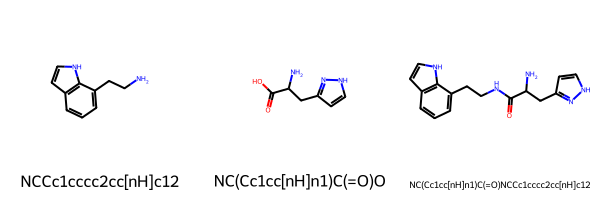

In [34]:
draw_row(df.iloc[0])

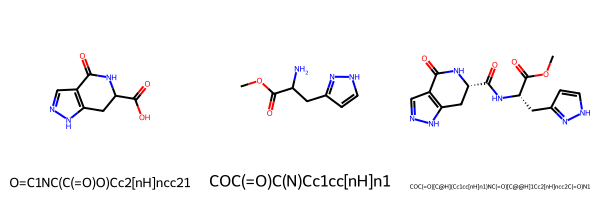

In [35]:
draw_row(df.iloc[1])